In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
Path to dataset files: /kaggle/input/online-retail-ii-uci


Решаем задачу бинарной классификации:

1 → счет-фактура (invoice) является «высокого значения» (сумма выше медианы всех счетов).

0 → счет-фактура «низкого значения» (сумма ≤ медианы).


Training logreg ...
Accuracy: 0.8051
ROC-AUC: 0.8547
              precision    recall  f1-score   support

           0       0.67      0.52      0.58     54561
           1       0.84      0.91      0.87    153773

    accuracy                           0.81    208334
   macro avg       0.75      0.71      0.73    208334
weighted avg       0.79      0.81      0.80    208334


Training rf ...
Accuracy: 0.8510
ROC-AUC: 0.9139
              precision    recall  f1-score   support

           0       0.76      0.64      0.69     54561
           1       0.88      0.93      0.90    153773

    accuracy                           0.85    208334
   macro avg       0.82      0.78      0.80    208334
weighted avg       0.85      0.85      0.85    208334



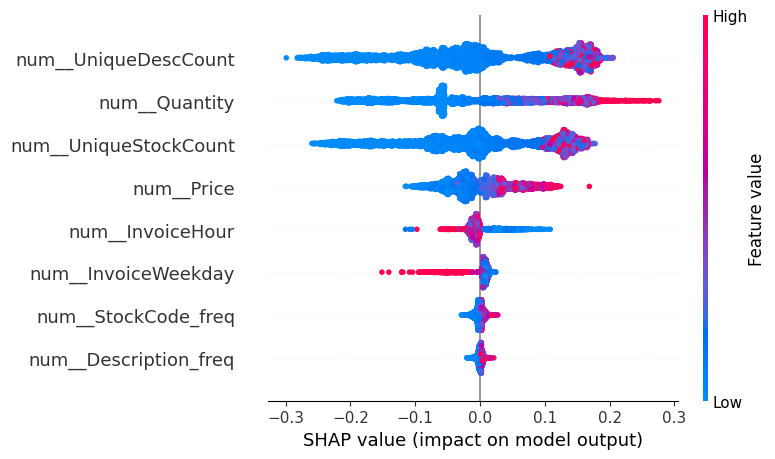


Top features:
                 feature  importance
5   num__UniqueDescCount    0.099654
1          num__Quantity    0.096717
4  num__UniqueStockCount    0.085176
0             num__Price    0.037797
6       num__InvoiceHour    0.013882
7    num__InvoiceWeekday    0.012969
3    num__StockCode_freq    0.004608
2  num__Description_freq    0.002753


In [ ]:
# ==============================
# 1. Импорт библиотек
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

import shap
import matplotlib.pyplot as plt


# ==============================
# 2. Загрузка данных
# ==============================

df = pd.read_csv(path+"/online_retail_II.csv")

# корректное преобразование даты
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# удалим строки где дата не распарсилась
df = df.dropna(subset=["InvoiceDate"])


# ==============================
# 3. Базовая очистка
# ==============================

# признак возврата
df["is_cancellation"] = df["Invoice"].astype(str).str.startswith("C")

# удалим возвраты
df = df[~df["is_cancellation"]]

# удалим отрицательные значения
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

# создадим сумму строки
df["LineTotal"] = df["Quantity"] * df["Price"]


# ==============================
# 4. Feature Engineering
# ==============================

# временные признаки
df["InvoiceHour"] = df["InvoiceDate"].dt.hour
df["InvoiceWeekday"] = df["InvoiceDate"].dt.weekday

# frequency encoding
df["Description_freq"] = df.groupby("Description")["Description"].transform("count")
df["StockCode_freq"] = df.groupby("StockCode")["StockCode"].transform("count")

# агрегаты по invoice
agg = df.groupby("Invoice").agg(
    UniqueStockCount=("StockCode", "nunique"),
    UniqueDescCount=("Description", "nunique")
)

df = df.merge(agg, on="Invoice", how="left")


# ==============================
# 5. Target (без leakage)
# ==============================

invoice_total = df.groupby("Invoice")["LineTotal"].sum()

median_total = invoice_total.median()

df = df.merge(invoice_total.rename("InvoiceTotal"), on="Invoice")

df["high_value_invoice"] = (df["InvoiceTotal"] > median_total).astype(int)


# ==============================
# 6. Признаки модели
# ==============================

features = [
    "Price",
    "Quantity",
    "Description_freq",
    "StockCode_freq",
    "UniqueStockCount",
    "UniqueDescCount",
    "InvoiceHour",
    "InvoiceWeekday"
]

target = "high_value_invoice"

X = df[features]
y = df[target]


# ==============================
# 7. Train / Test split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# ==============================
# 8. Preprocessing pipeline
# ==============================

numeric_features = features

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)


# ==============================
# 9. Модели
# ==============================

models = {

    "logreg": Pipeline(
        steps=[
            ("preproc", preprocessor),
            ("model", LogisticRegression(max_iter=1000))
        ]
    ),

    "rf": Pipeline(
        steps=[
            ("preproc", preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=50,
                max_depth=8,
                random_state=42,
                n_jobs=-1
            ))
        ]
    )
}


# ==============================
# 10. Обучение
# ==============================

results = {}

for name, pipe in models.items():

    print(f"\nTraining {name} ...")

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    acc = accuracy_score(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}")

    if roc:
        print(f"ROC-AUC: {roc:.4f}")

    print(classification_report(y_test, y_pred))

    results[name] = pipe


# ==============================
# 11. SHAP интерпретация
# ==============================

rf_model = results["rf"]

preproc = rf_model.named_steps["preproc"]
model = rf_model.named_steps["model"]

X_test_trans = preproc.transform(X_test)

feature_names = preproc.get_feature_names_out()

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_trans[:5000])
shap_vals = shap_values[:, :, 1]

shap.summary_plot(
    shap_vals,
    X_test_trans[:5000],
    feature_names=feature_names
)


# ==============================
# 12. Важность признаков
# ==============================

mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": mean_abs_shap
}).sort_values("importance", ascending=False)

print("\nTop features:")

print(importance.head(10))

чем больше разных товаров в корзине → тем выше вероятность положительного класса.

Интерпретация:

разнообразные корзины выглядят более “значимыми” для модели

однотипные покупки → менее вероятный целевой класс.